# Tutorial

how to use the longitudinal equilibrium code from the github repository:
        
    https://github.com/lnls-fac/collective_effects

This reference describes the algorithms implemented in the code:

    https://journals.aps.org/prab/abstract/10.1103/PhysRevAccelBeams.26.094402

# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pycolleff.longitudinal_equilibrium import ImpedanceSource, LongitudinalEquilibrium
import pycolleff.rings.sirius as sirius
import pycolleff.impedances as imp
import pycolleff.materials_params as mat_par


# Define Methods

In [2]:
def calculate_longitudinal_equilibrium(ring, impedance_sources, fill=None):
    """
    Calculate longitudinal equilibrium.
    """
    identical = False
    if fill is None:
        fill = np.ones(ring.harm_num) / ring.harm_num
    if np.unique(fill).size == 1:
        identical = True
    longeq = LongitudinalEquilibrium(
        ring=ring, impedance_sources=impedance_sources, fillpattern=fill)
    longeq.feedback_on = False  # main cavity is simulated with effective impedance
    longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
    longeq.max_mode = 1000*ring.harm_num  # define maximum frequency to consider
    longeq.min_mode0_ratio = 1e-10  # criteria for convergence
    longeq.identical_bunches = identical

    print('Calculating Longitudinal Equilibrium...')
    _ = longeq.calc_longitudinal_equilibrium(
        niter=100_000, tol=1e-8, beta=0.1, m=5, print_flag=False)
    print('Done!')
    return longeq


def print_results(longeq, uniform=True):
    """
    Print and plot the results of longitudinal equilibrium.
    """
    z0, sigmaz = longeq.calc_moments(longeq.zgrid, longeq.distributions)
    if uniform:
        print(f'Bunch 0 centroid: {z0[0]*1e3:.2f} mm')
        print(f'Bunch 0 length: {sigmaz[0]*1e3:.2f} mm')
        plt.figure()
        plt.plot(longeq.zgrid*1e3, longeq.distributions[0])
        plt.xlabel(r'$z$ [mm]')
        plt.ylabel(r'$\lambda(z)$ [1/mm]')
        plt.xlim(-50, 50)
        plt.tight_layout()
        plt.show()
    else:
        fig, (af, ax, ay) = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
        fill = longeq.fillpattern.copy()
        idcs = np.arange(fill.size)
        zef = np.isclose(fill, 0)
        af.plot(idcs, fill*longeq.ring.total_current*1e3, 'o')
        ax.plot(idcs[~zef], z0[~zef]*1e3, 'o')
        ay.plot(idcs[~zef], sigmaz[~zef]*1e3, 'o')
        ax.plot(idcs[zef], z0[zef]*1e3, 'o', color='gray')
        ay.plot(idcs[zef], sigmaz[zef]*1e3, 'o', color='gray')
        af.set_ylabel('Filling Pattern [mA]')
        ax.set_ylabel('Centroid [mm]')
        ay.set_ylabel('Bunch Length [mm]')
        ay.set_xlabel('Bunch Index')
        fig.tight_layout()
        plt.show()


# Create the model of the ring

In [20]:
ring = sirius.create_ring()
ring.en_lost_rad = 870e3
ring.gap_voltage = 3.0e6
ring.total_current = 350e-3
print(ring)


Lattice Version             :   SI.v25.01-s05.02  
Circumference [m]           :       518.387       
Revolution Period [us]      :        1.729        
Revolution Frequency [kHz]  :       578.318       
Energy [GeV]                :        3.000        
U0 [keV]                    :       870.000       
Vgap [MV]                   :        3.000        
Momentum Compaction         :       1.63e-04      
Harmonic Number             :         864         
Current [mA]                :       350.000       
Current per Bunch [mA]      :        0.405        
Synchrotron Tune            :       0.00356       
Tunes x/y                   :    49.078/14.137    
Chromaticities x/y          :     2.500/2.500     
Damping Times x/y/e [ms]    :   16.9/ 22.0 /12.9  
Energy Spread [%]           :        0.0887       
Bunch Length [mm]           :        3.250        



# Active Main Cavity

In [21]:
mcav = ImpedanceSource()
mcav.harm_rf = 1
Q0 = 2e9
Qext = 1.58e5
iQ = 1 / Q0 + 1 / Qext
Q = 1 / iQ
mcav.Q = Q
nmcs = 2
RoverQ = 89
mcav.shunt_impedance = nmcs * RoverQ * mcav.Q
twopi = 2 * np.pi
wrf = twopi * ring.rf_freq
mcav.ang_freq_rf = wrf

mcav.ref_amp = ring.gap_voltage
mcav.ref_phase = ring.sync_phase

# df = -4.9e3
df = mcav.optimum_detuning_freq(beam_current=ring.total_current)
mcav.res_ang_freq = mcav.harm_rf * wrf
mcav.detune_w = twopi * df

mcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
mcav.active_passive = ImpedanceSource.ActivePassive.Active

# If you do not want to worry about the details of the voltage gap
# control system, you can use SIRIUS parameters below.
delay = 1.9e-6
ki = 0.01
kp = 2.96e-6
kd = 0
gain = 1
mcav.loop_ctrl_ang_freq = twopi * ring.rf_freq
mcav.loop_ctrl_kpid = [kp, ki, kd]
mcav.loop_ctrl_overall_gain = gain
mcav.loop_ctrl_delay = delay
mcav.loop_ctrl_transfer = mcav.pid_transfer_func
print(mcav)

calc_method              : ImpedanceDFT  
active_passive           : Active  
ang_freq_rf              : 3139.50  [Mrad/s]
ang_freq                 : 3139.44  [Mrad/s]
shunt_impedance          : 28.12  [MOhm]
Q                        : 1.58e+05  
RoverQ                   : 178.00  [Ohm]
beta_coupling            : 0.00  
harm_rf                  : 1.00  
detune_angle             : -1.41  [rad]
detune_freq              : -9.93  [kHz]
detune_w                 : -62.40  [krad/s]
alpha                    : 9935.71  [rad/s]
ang_freq_bar             : 3139.44  [Mrad/s]
loaded_shunt_impedance   : 28.12  [MOhm]
loaded_Q                 : 1.58e+05  
feedback_on              : False  
feedback_method          : Phasor  
ref_amp                  : 3000.00  [kV]
ref_phase                : 163.14  [deg]



In [22]:
longeq = calculate_longitudinal_equilibrium(ring, [mcav])


Calculating Longitudinal Equilibrium...
Done!


Bunch 0 centroid: -0.01 mm
Bunch 0 length: 2.57 mm


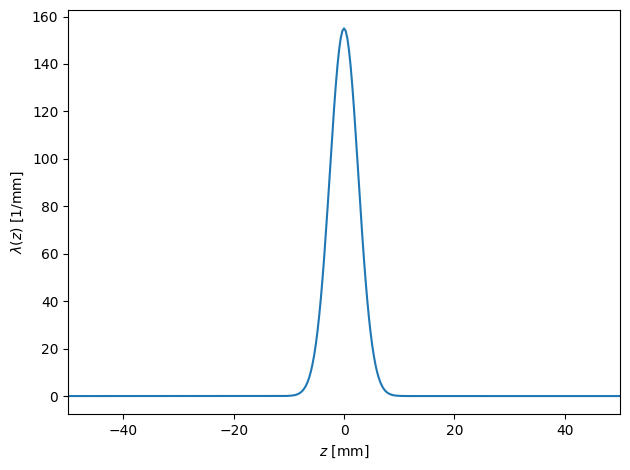

In [23]:
print_results(longeq)


# Passive Hamonic Cavity

In [24]:
hcav = ImpedanceSource()
hcav.harm_rf = 3
hcav.Q = 4e8
RoverQ = 87.5
hcav.shunt_impedance = RoverQ * hcav.Q
twopi = 2 * np.pi
wrf = twopi * ring.rf_freq
df = 45e3
hcav.ang_freq_rf = wrf
hcav.res_ang_freq = hcav.harm_rf * wrf
hcav.detune_w = twopi * df
hcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
hcav.active_passive = ImpedanceSource.ActivePassive.Passive
print(hcav)


calc_method              : ImpedanceDFT  
active_passive           : Passive  
ang_freq_rf              : 3139.50  [Mrad/s]
ang_freq                 : 9418.78  [Mrad/s]
shunt_impedance          : 35000.00  [MOhm]
Q                        : 4.00e+08  
RoverQ                   : 87.50  [Ohm]
beta_coupling            : 0.00  
harm_rf                  : 3.00  
detune_angle             : 1.57  [rad]
detune_freq              : 45.00  [kHz]
detune_w                 : 282.74  [krad/s]
alpha                    : 11.77  [rad/s]
ang_freq_bar             : 9418.78  [Mrad/s]



In [25]:
longeq = calculate_longitudinal_equilibrium(ring, [mcav, hcav, ])


Calculating Longitudinal Equilibrium...
Done!


Bunch 0 centroid: -0.23 mm
Bunch 0 length: 11.85 mm


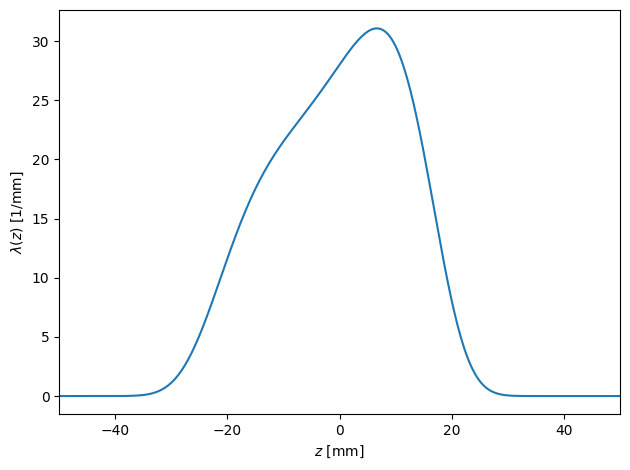

In [26]:
print_results(longeq)


# Broadband Resonators

In [27]:
# These 2 BBRs have numerical problems for Wake (space-domain) method
# No problem for Impedance (frequency-domain) method
frs =    [716.2, 206.9]
qs =     [0.7, 1.3]
shunts = [30.0,   6.5]

frs +=    [138.4, 79.6, 57.3, 35.0, 17.8, 17.5,  11.9,   9.2,   0.888,   0.176,]
qs +=     [  4.0,  1.0,  4.5,  3.0,  1.0, 24.0,  24.0, 100.0, 261.0, 263.0,]
shunts += [  2.0,  2.0,  2.5,  2.5,  1.7,  3.0,   4.0,  20.0,   7.0,   6.0,]

frs = np.array(frs)*1e9  # GHz -> Hz
qs = np.array(qs)
shunts = np.array(shunts)*1e3  # kOhm -> Ohms

freq_rf = ring.rf_freq
bbrs = []
for res_freq, shunt, qfactor in zip(frs, shunts, qs):
    bbr = ImpedanceSource()
    bbr.Q = qfactor
    bbr.shunt_impedance = shunt
    bbr.harm_rf = 1
    bbr.ang_freq_rf = 2*np.pi*freq_rf
    bbr.res_ang_freq = 2*np.pi*res_freq

    # Methods: Impedance or Wake
    bbr.calc_method = ImpedanceSource.Methods.ImpedanceDFT
    # harm_cav.calc_method = ImpedanceSource.Methods.Wake

    # Device type: Active of Passive
    bbr.active_passive = ImpedanceSource.ActivePassive.Passive
    bbrs.append(bbr)


In [28]:
longeq = calculate_longitudinal_equilibrium(ring, [mcav] + bbrs)


Calculating Longitudinal Equilibrium...
Done!


Bunch 0 centroid: -0.60 mm
Bunch 0 length: 3.07 mm


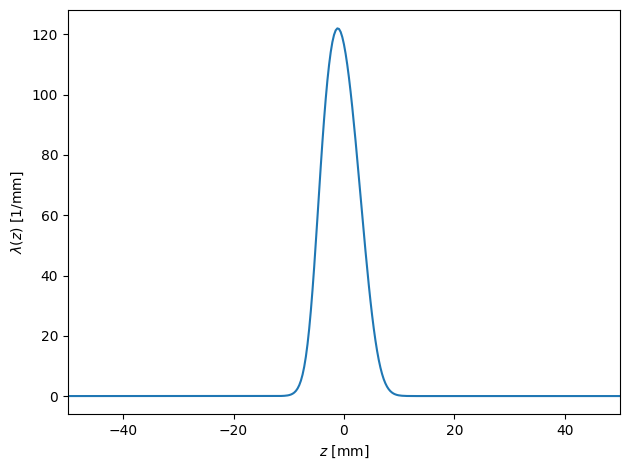

In [29]:
print_results(longeq)


# Generic Impedance Sources

Any impedance table can be used for calculation of the equilibrium.

Here, we calculate the multilayer resistive wall impedance of a round chamber to use as example of a generic impedance.

## Calculate Multilayer Resistive Wall Impedance

In [30]:
cu_cond = mat_par.cu_cond
cu_rel_time = mat_par.cu_rel_time
neg_cond = mat_par.neg_cond
neg_rel_time = mat_par.neg_rel_time
neg_thick = mat_par.neg_thick
ndfe_cond = mat_par.ndfe_cond
ndfe_mur = mat_par.ndfe_mur

energy = 3e9  # [eV]
length = 500  # [m] ~ ring size not considering IDs and injection

epb = np.array([1, 1, 1, 1, 1])
mub = np.array([1, 1, 1, 1, ndfe_mur])
ange = np.array([0, 0, 0, 0, 0])
angm = np.array([0, 0, 0, 0, 0])
sigmadc = np.array([0, neg_cond, cu_cond, 0, ndfe_cond])
tau = np.array([0, neg_rel_time, cu_rel_time, 0, 0])

radius = 12e-3 + np.array([-neg_thick, 0, 1e-3, 3e-3])

ang_freq = imp.get_default_reswall_w(radius=radius[0], energy=energy)

epr, mur = imp.prepare_inputs_epr_mur(
    ang_freq, epb, mub, ange, angm, sigmadc, tau)

Zll, Zdx, Zdy = imp.multilayer_round_chamber(
    ang_freq,
    length,
    energy,
    epr,
    mur,
    radius,
    precision=70,
    wmax_arb_prec=1e12,
    arb_prec_incl_long=False,
    print_progress=False,
)

Zll, ang_freq = imp.get_impedance_for_negative_w(
    Zll, ang_freq, impedance_type='ll'
)


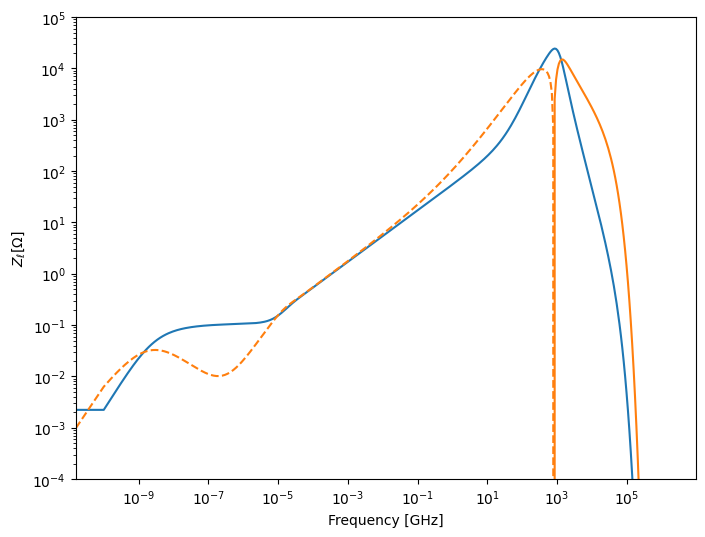

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

freq = ang_freq/2/np.pi * 1e-9  # [GHz]

ax.plot(freq, Zll.real)
ax.plot(freq, Zll.imag)
ax.plot(freq, -Zll.imag, '--', color='C1')

ax.set_ylabel(r'$Z_\ell [\Omega]$')
ax.set_xlabel('Frequency [GHz]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-4, 1e5)
plt.show()


## Calculate Equilibrium

In [32]:
generic = ImpedanceSource()
generic.zl_table = Zll
generic.ang_freq_table = ang_freq

# Methods: Impedance or Wake
generic.calc_method = ImpedanceSource.Methods.ImpedanceDFT

# Device type: Active of Passive
generic.active_passive = ImpedanceSource.ActivePassive.Passive


In [33]:
longeq = calculate_longitudinal_equilibrium(ring, [mcav, generic, ])


Calculating Longitudinal Equilibrium...
Done!


Bunch 0 centroid: -0.14 mm
Bunch 0 length: 2.77 mm


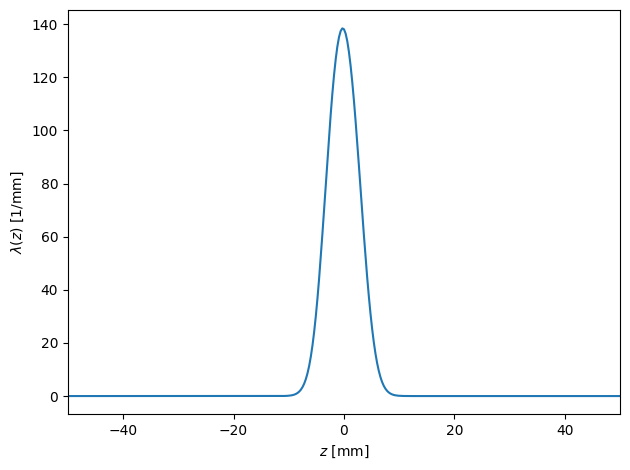

In [34]:
print_results(longeq)


# Several Impedance Sources

In [35]:
longeq = calculate_longitudinal_equilibrium(ring, [mcav, hcav, generic])

Calculating Longitudinal Equilibrium...
Done!


Bunch 0 centroid: -0.25 mm
Bunch 0 length: 11.93 mm


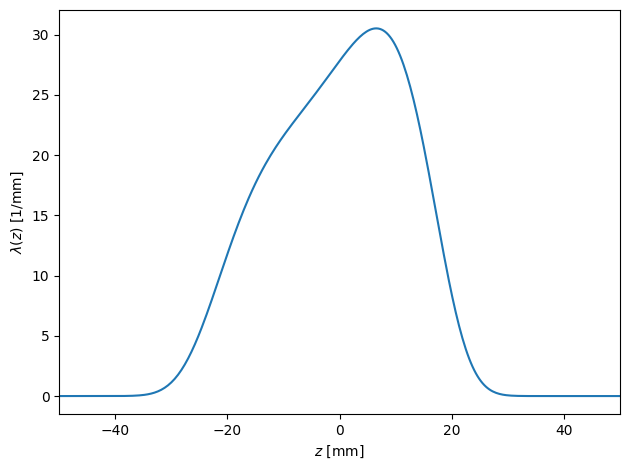

In [36]:
print_results(longeq)


# Non-uniform Filling Patterns

In [37]:
fill = 1 - 0.9*np.sin(2*np.pi*np.arange(ring.harm_num)/ring.harm_num)
fill[500:600] = 0
fill /=  fill.sum()
longeq = calculate_longitudinal_equilibrium(ring, [mcav, hcav, generic], fill=fill)


Calculating Longitudinal Equilibrium...
Done!


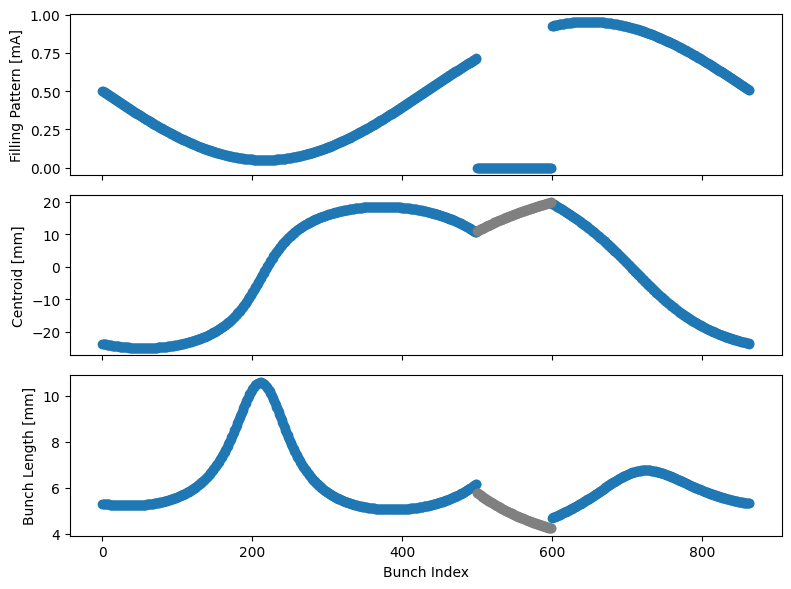

In [38]:
print_results(longeq, uniform=False)
